Temporal Analysis

In [0]:
# Import required libraries
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Load Data
df = spark.table("data_processed.credit_risk_main.loans_transformed")

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [0]:
# Step 1: Check if issue_date exists
if "issue_date" not in df.columns:
    raise ValueError("The column 'issue_date' is not available in the dataset.")

In [0]:
# Step 2: Load required columns
time_cols = ["issue_date", "loan_amnt"]
existing_cols = [c for c in time_cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

In [0]:
# Step 3: Convert issue_date to datetime
pdf["issue_date"] = pd.to_datetime(pdf["issue_date"], errors="coerce")

In [0]:
# Drop missing dates
pdf = pdf.dropna(subset=["issue_date"])

In [0]:
# Step 4: Aggregate by month
pdf["issue_month"] = pdf["issue_date"].dt.to_period("M").dt.to_timestamp()
loan_trends = pdf.groupby("issue_month").agg(
    loans_issued=("loan_amnt", "count"),
    total_amount=("loan_amnt", "sum")
).reset_index()

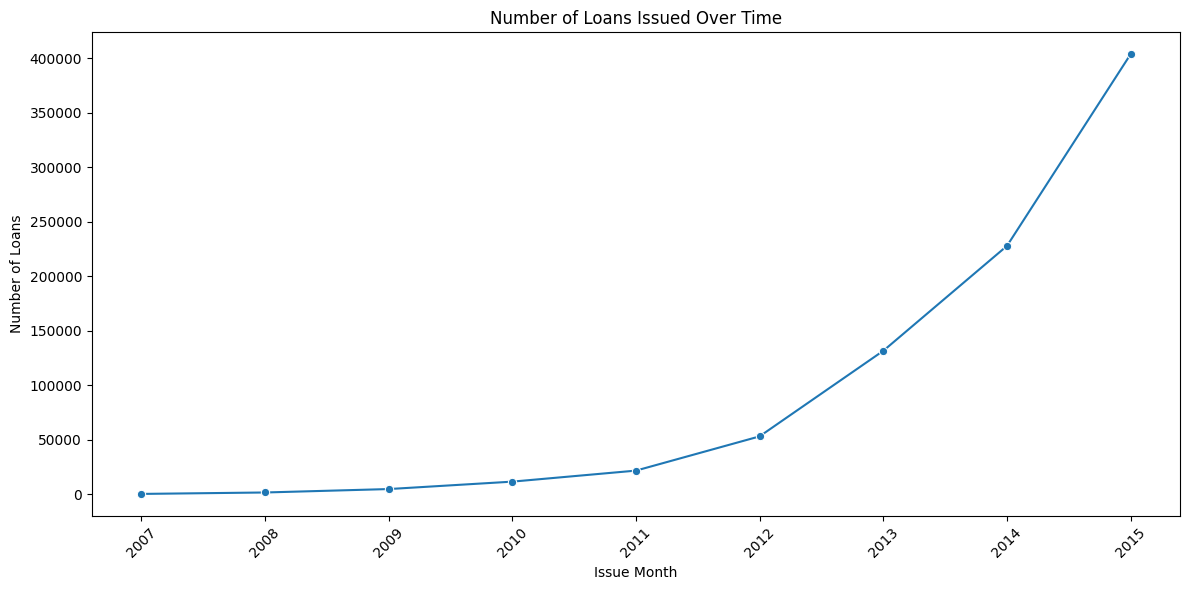

In [0]:
# Step 5: Plot number of loans issued over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=loan_trends, x="issue_month", y="loans_issued", marker="o")
plt.title("Number of Loans Issued Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Number of Loans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

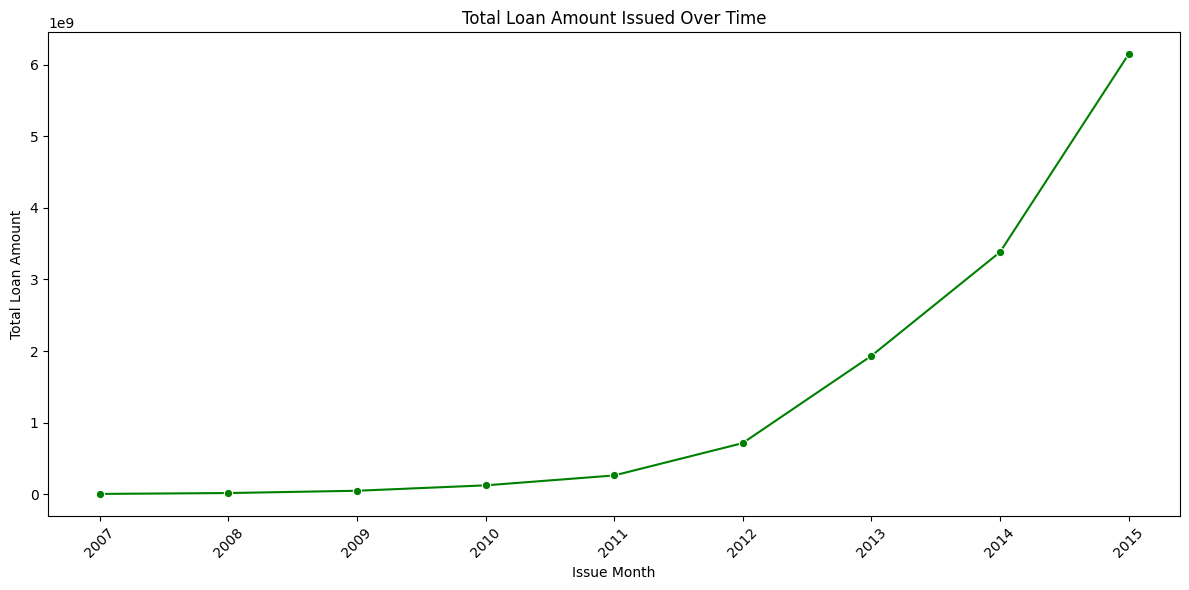

In [0]:
# Step 6: Plot total loan amount issued over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=loan_trends, x="issue_month", y="total_amount", marker="o", color="green")
plt.title("Total Loan Amount Issued Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Total Loan Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

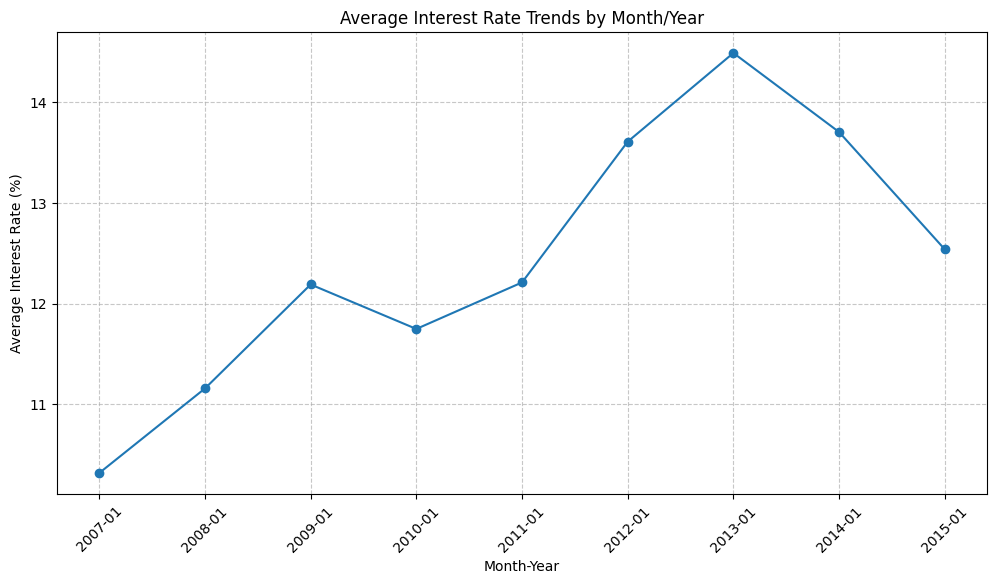

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load required columns
cols = ["issue_date", "int_rate"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

# Ensure issue_date is datetime
if 'issue_date' in pdf.columns and 'int_rate' in pdf.columns:
    pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')
    
    # Extract Year-Month
    pdf['year_month'] = pdf['issue_date'].dt.to_period('M')
    
    # Group by year-month and calculate average interest rate
    avg_int_rate = pdf.groupby('year_month')['int_rate'].mean().reset_index()
    avg_int_rate['year_month'] = avg_int_rate['year_month'].astype(str)
    
    # Plot trend
    plt.figure(figsize=(12,6))
    plt.plot(avg_int_rate['year_month'], avg_int_rate['int_rate'], marker='o')
    plt.xticks(rotation=45)
    plt.title("Average Interest Rate Trends by Month/Year")
    plt.xlabel("Month-Year")
    plt.ylabel("Average Interest Rate (%)")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()
else:
    print("Column 'issue_date' not found in dataset.")

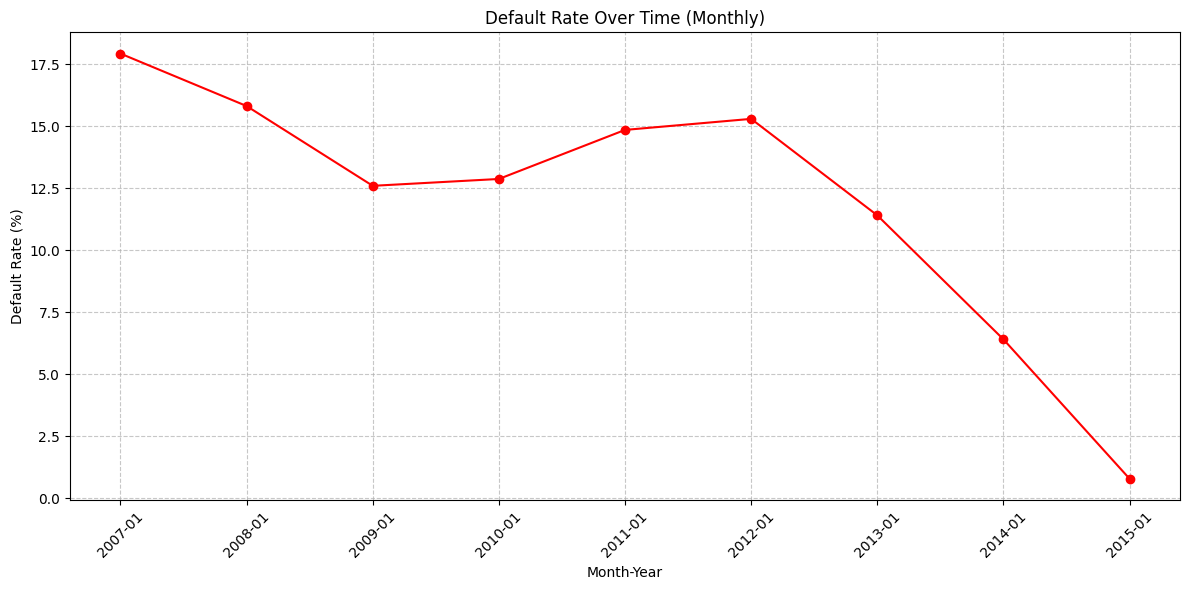

In [0]:
# Default rate over time

# Step 1: Select required columns
cols = ["issue_date", "default_ind"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

if "issue_date" in pdf.columns and "default_ind" in pdf.columns:
    # Ensure datetime format
    pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')
    
    # Extract Year-Month
    pdf['year_month'] = pdf['issue_date'].dt.to_period("M")
    
    # Step 2: Calculate default rate by month
    default_rate = (
        pdf.groupby('year_month')['default_ind']
        .mean()  # mean works since default_ind is 0/1
        .reset_index()
    )
    default_rate['year_month'] = default_rate['year_month'].astype(str)
    default_rate['default_rate'] = default_rate['default_ind'] * 100  # percentage
    
    # Step 3: Plot default rate trend
    plt.figure(figsize=(12,6))
    plt.plot(default_rate['year_month'], default_rate['default_rate'], marker='o', color='red')
    plt.xticks(rotation=45)
    plt.title("Default Rate Over Time (Monthly)")
    plt.xlabel("Month-Year")
    plt.ylabel("Default Rate (%)")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Missing required columns: {set(cols) - set(pdf.columns)}")

Dual-axis plot:

Bar plot (loan count per month)

Line plot (default rate per month, %)

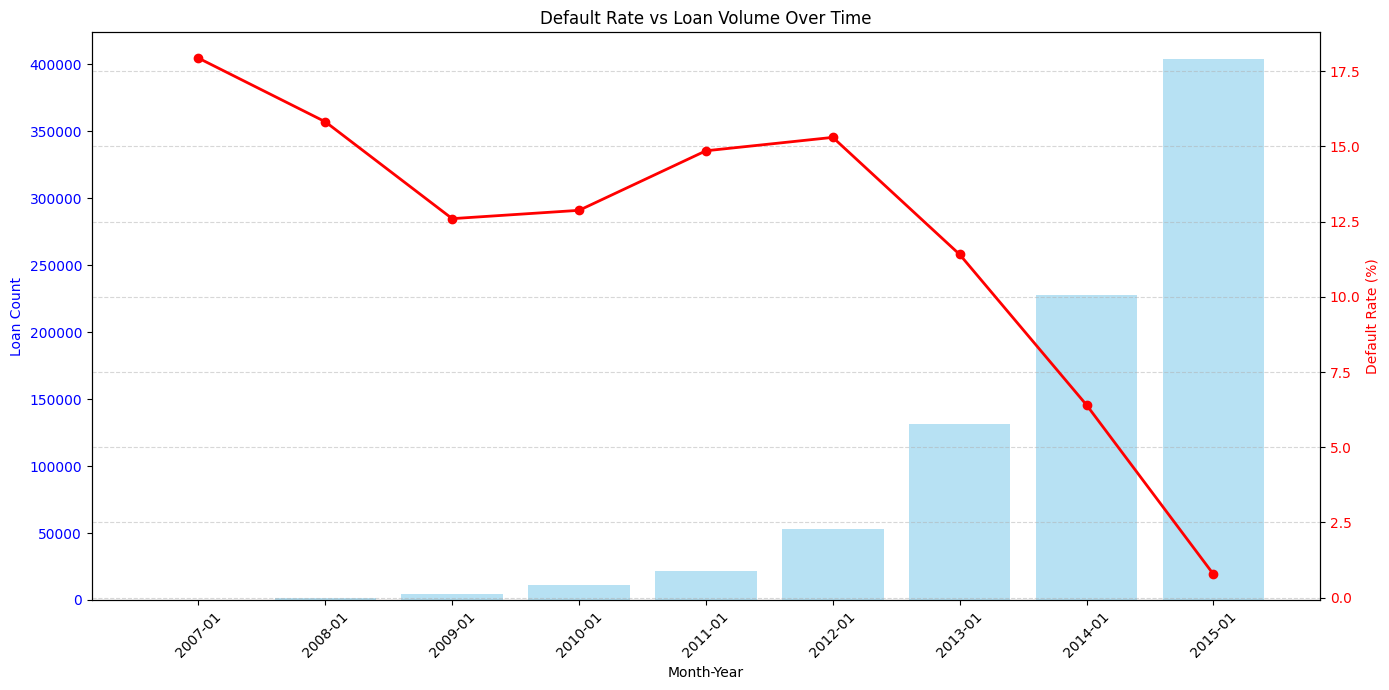

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Select required columns
cols = ["issue_date", "default_ind"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

if "issue_date" in pdf.columns and "default_ind" in pdf.columns:
    # Ensure datetime format
    pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')
    
    # Extract Year-Month
    pdf['year_month'] = pdf['issue_date'].dt.to_period("M")
    
    # Step 2: Aggregate
    monthly_stats = (
        pdf.groupby('year_month')
        .agg(
            loan_count=('default_ind', 'count'),
            default_rate=('default_ind', 'mean')
        )
        .reset_index()
    )
    monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
    monthly_stats['default_rate'] *= 100  # convert to percentage
    
    # Step 3: Plot with dual axes
    fig, ax1 = plt.subplots(figsize=(14,7))

    # Loan volume (bar)
    ax1.bar(monthly_stats['year_month'], monthly_stats['loan_count'], 
            color='skyblue', alpha=0.6, label="Loan Count")
    ax1.set_xlabel("Month-Year")
    ax1.set_ylabel("Loan Count", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(range(0, len(monthly_stats), max(1, len(monthly_stats)//12)))
    ax1.set_xticklabels(monthly_stats['year_month'][::max(1, len(monthly_stats)//12)], rotation=45)

    # Default rate (line)
    ax2 = ax1.twinx()
    ax2.plot(monthly_stats['year_month'], monthly_stats['default_rate'], 
             color='red', marker='o', linewidth=2, label="Default Rate (%)")
    ax2.set_ylabel("Default Rate (%)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Title and grid
    plt.title("Default Rate vs Loan Volume Over Time")
    fig.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

else:
    print(f"Missing required columns: {set(cols) - set(pdf.columns)}")


3-month rolling averages for both:

Loan volume (loans issued)

Average interest rate

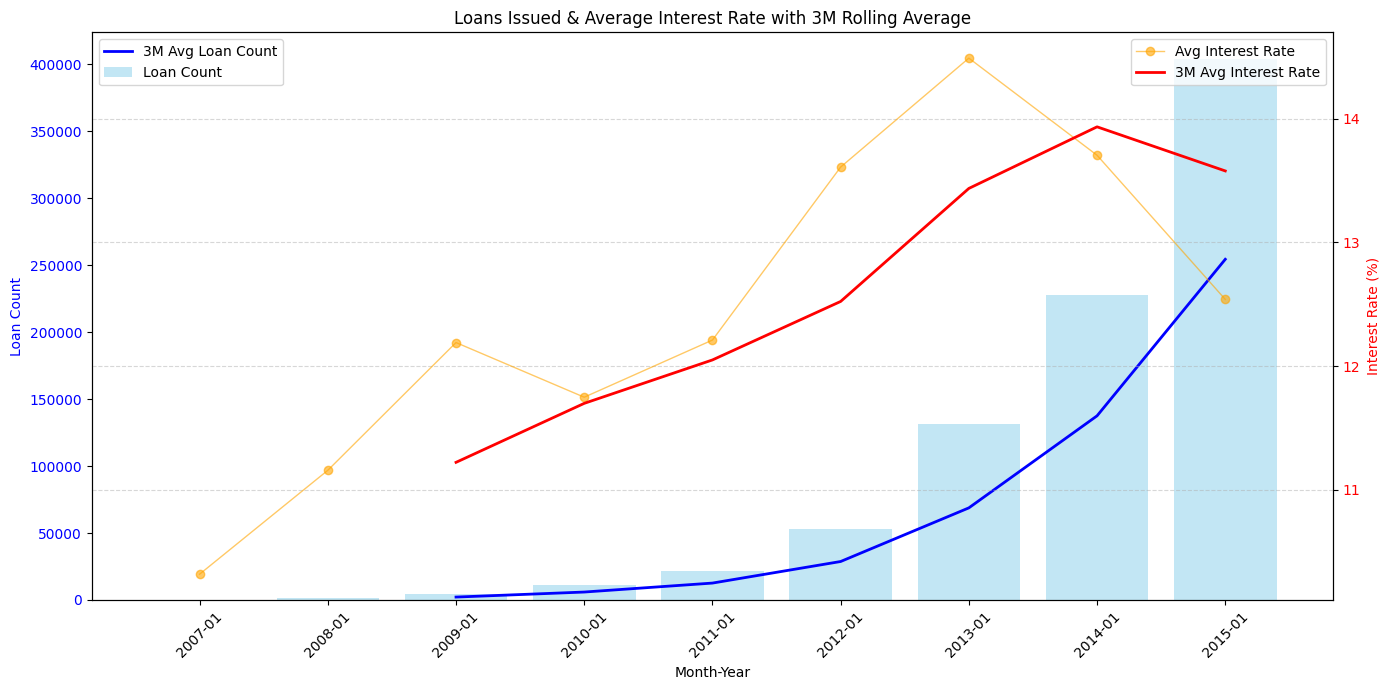

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Select required columns
cols = ["issue_date", "int_rate"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

if "issue_date" in pdf.columns and "int_rate" in pdf.columns:
    # Ensure datetime format
    pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')
    
    # Extract Year-Month
    pdf['year_month'] = pdf['issue_date'].dt.to_period("M")
    
    # Step 2: Aggregate by month
    monthly_stats = (
        pdf.groupby('year_month')
        .agg(
            loan_count=('int_rate', 'count'),
            avg_int_rate=('int_rate', 'mean')
        )
        .reset_index()
    )
    monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
    
    # Step 3: Apply 3-month rolling average
    monthly_stats['loan_count_3m_avg'] = monthly_stats['loan_count'].rolling(3).mean()
    monthly_stats['avg_int_rate_3m_avg'] = monthly_stats['avg_int_rate'].rolling(3).mean()
    
    # Step 4: Plot trends
    fig, ax1 = plt.subplots(figsize=(14,7))

    # Loan volume (bar + rolling avg line)
    ax1.bar(monthly_stats['year_month'], monthly_stats['loan_count'], 
            color='skyblue', alpha=0.5, label="Loan Count")
    ax1.plot(monthly_stats['year_month'], monthly_stats['loan_count_3m_avg'], 
             color='blue', linewidth=2, label="3M Avg Loan Count")
    ax1.set_xlabel("Month-Year")
    ax1.set_ylabel("Loan Count", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(range(0, len(monthly_stats), max(1, len(monthly_stats)//12)))
    ax1.set_xticklabels(monthly_stats['year_month'][::max(1, len(monthly_stats)//12)], rotation=45)

    # Average interest rate (line + rolling avg)
    ax2 = ax1.twinx()
    ax2.plot(monthly_stats['year_month'], monthly_stats['avg_int_rate'], 
             color='orange', alpha=0.6, marker='o', linewidth=1, label="Avg Interest Rate")
    ax2.plot(monthly_stats['year_month'], monthly_stats['avg_int_rate_3m_avg'], 
             color='red', linewidth=2, label="3M Avg Interest Rate")
    ax2.set_ylabel("Interest Rate (%)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Title and grid
    plt.title("Loans Issued & Average Interest Rate with 3M Rolling Average")
    fig.tight_layout()
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

else:
    print(f"Missing required columns: {set(cols) - set(pdf.columns)}")


Combined visualization showing:

Loan volume (bars + 3-month rolling avg)

Average interest rate (line + 3-month rolling avg)

Default rate (line + 3-month rolling avg)

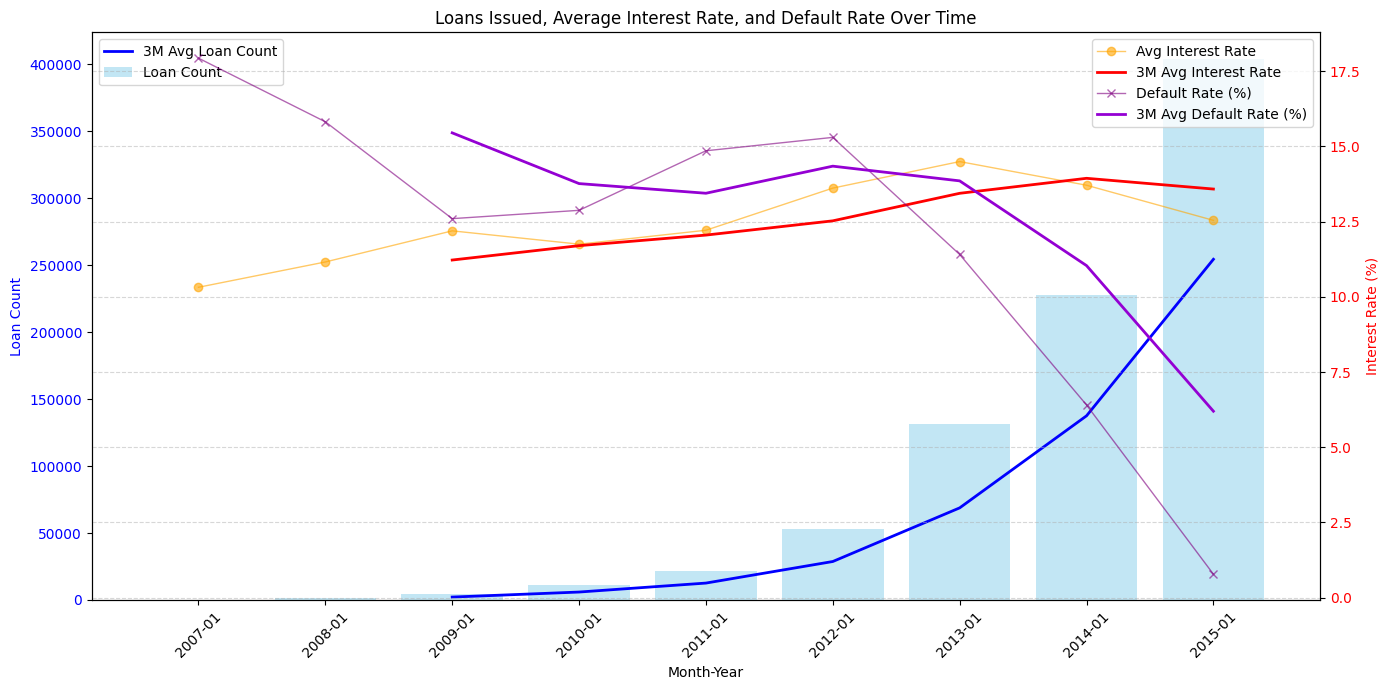

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Select required columns
cols = ["issue_date", "int_rate", "default_ind"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

# Ensure all columns exist
if all(c in pdf.columns for c in ["issue_date", "int_rate", "default_ind"]):
    # Convert issue_date to datetime
    pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')
    
    # Extract Year-Month
    pdf['year_month'] = pdf['issue_date'].dt.to_period("M")
    
    # Step 2: Aggregate by month
    monthly_stats = (
        pdf.groupby('year_month')
        .agg(
            loan_count=('int_rate', 'count'),
            avg_int_rate=('int_rate', 'mean'),
            default_rate=('default_ind', 'mean')
        )
        .reset_index()
    )
    monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
    
    # Convert default rate to percentage
    monthly_stats['default_rate'] *= 100
    
    # Step 3: Compute 3-month rolling averages
    monthly_stats['loan_count_3m_avg'] = monthly_stats['loan_count'].rolling(3).mean()
    monthly_stats['avg_int_rate_3m_avg'] = monthly_stats['avg_int_rate'].rolling(3).mean()
    monthly_stats['default_rate_3m_avg'] = monthly_stats['default_rate'].rolling(3).mean()
    
    # Step 4: Plot combined trends
    fig, ax1 = plt.subplots(figsize=(14,7))

    # Loan volume
    ax1.bar(monthly_stats['year_month'], monthly_stats['loan_count'], color='skyblue', alpha=0.5, label="Loan Count")
    ax1.plot(monthly_stats['year_month'], monthly_stats['loan_count_3m_avg'], color='blue', linewidth=2, label="3M Avg Loan Count")
    ax1.set_xlabel("Month-Year")
    ax1.set_ylabel("Loan Count", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticks(range(0, len(monthly_stats), max(1, len(monthly_stats)//12)))
    ax1.set_xticklabels(monthly_stats['year_month'][::max(1, len(monthly_stats)//12)], rotation=45)

    # Average interest rate
    ax2 = ax1.twinx()
    ax2.plot(monthly_stats['year_month'], monthly_stats['avg_int_rate'], color='orange', alpha=0.6, marker='o', linewidth=1, label="Avg Interest Rate")
    ax2.plot(monthly_stats['year_month'], monthly_stats['avg_int_rate_3m_avg'], color='red', linewidth=2, label="3M Avg Interest Rate")
    ax2.set_ylabel("Interest Rate (%)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Default rate
    ax2.plot(monthly_stats['year_month'], monthly_stats['default_rate'], color='purple', alpha=0.6, marker='x', linewidth=1, label="Default Rate (%)")
    ax2.plot(monthly_stats['year_month'], monthly_stats['default_rate_3m_avg'], color='darkviolet', linewidth=2, label="3M Avg Default Rate (%)")

    # Title, grid, and legends
    plt.title("Loans Issued, Average Interest Rate, and Default Rate Over Time")
    fig.tight_layout()
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

else:
    print(f"Missing required columns: {set(cols) - set(pdf.columns)}")


Combined visualization showing:

Loans issued over time (monthly)

Default rate (monthly %)

Recoveries over time (monthly total)

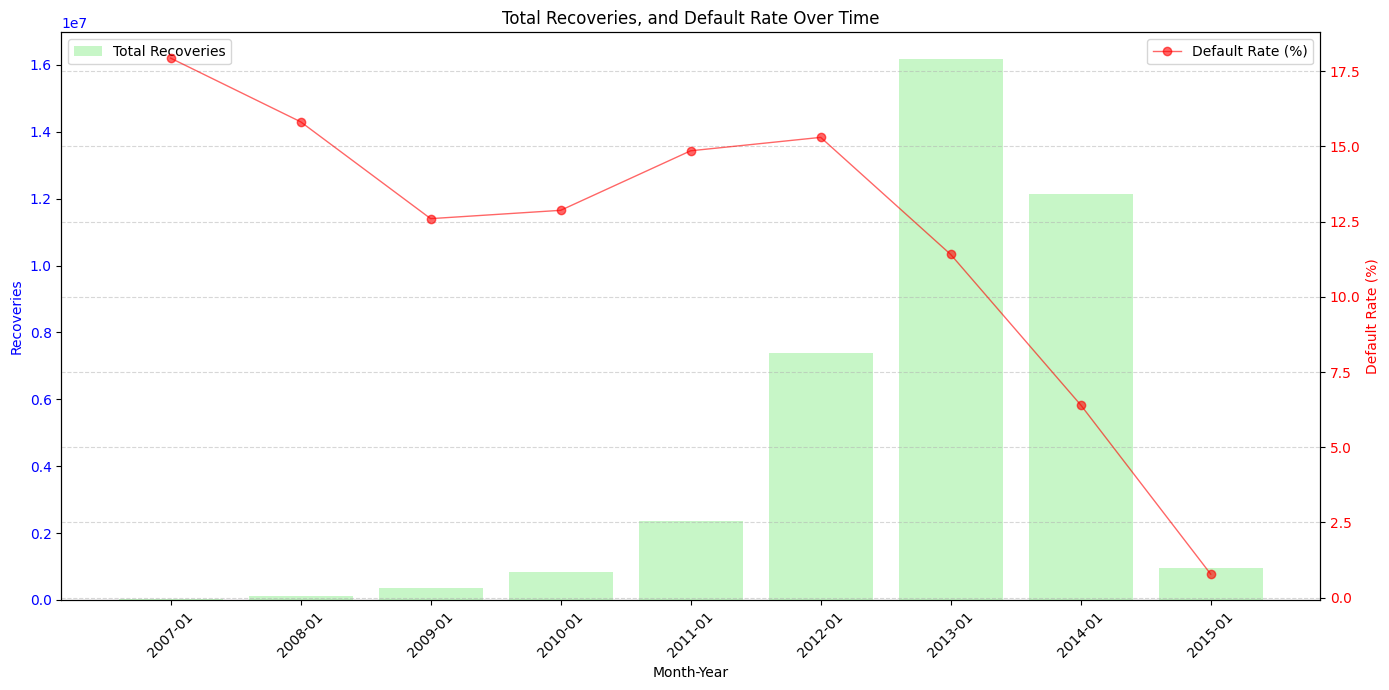

In [0]:
# Step 1: Select required columns
cols = ["issue_date", "default_ind", "loan_amnt", "recoveries"]
existing_cols = [c for c in cols if c in df.columns]

pdf = df.select(*existing_cols).toPandas()

# Ensure all required columns exist
missing_cols = set(cols) - set(pdf.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Step 2: Convert issue_date to datetime
pdf['issue_date'] = pd.to_datetime(pdf['issue_date'], errors='coerce')

# Extract Year-Month
pdf['year_month'] = pdf['issue_date'].dt.to_period("M")

# Step 3: Aggregate by month
monthly_stats = (
    pdf.groupby('year_month')
    .agg(
        loan_sum=('loan_amnt', 'sum'),
        total_recoveries=('recoveries', 'sum'),
        default_rate=('default_ind', 'mean')
    )
    .reset_index()
)
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
monthly_stats['default_rate'] *= 100  # convert to %

# Step 4: Compute 3-month rolling averages
# monthly_stats['loan_count_3m_avg'] = monthly_stats['loan_count'].rolling(3).mean()
# monthly_stats['recoveries_3m_avg'] = monthly_stats['total_recoveries'].rolling(3).mean()
# monthly_stats['default_rate_3m_avg'] = monthly_stats['default_rate'].rolling(3).mean()

# Step 5: Plot combined chart
fig, ax1 = plt.subplots(figsize=(14,7))

# Loan volume bars
# ax1.bar(monthly_stats['year_month'], monthly_stats['loan_sum'], color='skyblue', alpha=0.5, label="Loan Count")
# ax1.plot(monthly_stats['year_month'], monthly_stats['loan_count_3m_avg'], color='blue', linewidth=2, label="3M Avg Loan Count")

# Recoveries bars (overlaid)
ax1.bar(monthly_stats['year_month'], monthly_stats['total_recoveries'], 
        color='lightgreen', alpha=0.5, label="Total Recoveries")
# ax1.plot(monthly_stats['year_month'], monthly_stats['recoveries_3m_avg'], color='green', linewidth=2, label="3M Avg Recoveries")

ax1.set_xlabel("Month-Year")
ax1.set_ylabel("Recoveries", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(0, len(monthly_stats), max(1, len(monthly_stats)//12)))
ax1.set_xticklabels(monthly_stats['year_month'][::max(1, len(monthly_stats)//12)], rotation=45)

# Default rate line (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(monthly_stats['year_month'], monthly_stats['default_rate'], color='red', alpha=0.6, marker='o', linewidth=1, label="Default Rate (%)")
# ax2.plot(monthly_stats['year_month'], monthly_stats['default_rate_3m_avg'], color='darkred', linewidth=2, label="3M Avg Default Rate (%)")
ax2.set_ylabel("Default Rate (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title, grid, legends
plt.title("Total Recoveries, and Default Rate Over Time")
fig.tight_layout()
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
